# Correlation Matrix: `is_canceled` vs tất cả biến

**Mục tiêu:**
- Tính tương quan Pearson (biến số) và Cramér's V (biến phân loại) với `is_canceled`
- Vẽ heatmap ma trận tương quan
- Phân loại biến theo khả năng **causation** vs **correlation / leakage**

> **Lưu ý:** Correlation ≠ Causation. 
- Biến hậu quả (`reservation_status`, `revenue`,...) sẽ được đánh dấu riêng.

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]
    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file() -> Path:
    candidates: list[tuple[int, Path]] = []
    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            if "test" in file_path.name.lower():
                continue
            match = VERSION_PATTERN.match(file_path.name)
            if match:
                candidates.append((int(match.group(1)), file_path.resolve()))

    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy file '{DATA_BASENAME}_v*.csv'")

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


csv_path = find_latest_versioned_data_file()
print(f"Đang đọc: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Số booking: {len(df):,}")
print(f"Tỷ lệ hủy: {df['is_canceled'].mean() * 100:.2f}%")
print(f"Số cột: {len(df.columns)}")

Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv


Số booking: 82,811
Tỷ lệ hủy: 28.12%
Số cột: 36


## 1. Tương quan biến số (Pearson & Spearman)

In [2]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

pearson_corr = (
    df[num_cols]
    .corr()["is_canceled"]
    .drop("is_canceled")
    .sort_values(key=abs, ascending=False)
)

spearman_corr = pd.Series(
    {
        col: stats.spearmanr(df[col], df["is_canceled"], nan_policy="omit").statistic
        for col in num_cols
        if col != "is_canceled"
    }
).sort_values(key=abs, ascending=False)

corr_numeric = pd.DataFrame({
    "pearson": pearson_corr,
    "spearman": spearman_corr.reindex(pearson_corr.index),
})
corr_numeric["abs_pearson"] = corr_numeric["pearson"].abs()
corr_numeric = corr_numeric.sort_values("abs_pearson", ascending=False)

print("=== Top 15 |Pearson| với is_canceled ===")
display(corr_numeric.head(15).drop(columns="abs_pearson"))

=== Top 15 |Pearson| với is_canceled ===


,pearson,spearman
revenue,-0.494349,-0.769894
lead_time,0.195582,0.233251
required_car_parking_spaces,-0.188850,-0.190811
Occupancy_Rate,-0.163011,-0.158061
total_of_special_requests,-0.127511,-0.134917
adr,0.123334,0.137979
booking_changes,-0.093014,-0.123619
is_repeated_guest,-0.089968,-0.089968
arrival_date_year,0.089236,0.088446
RevPAR,0.083565,0.088171


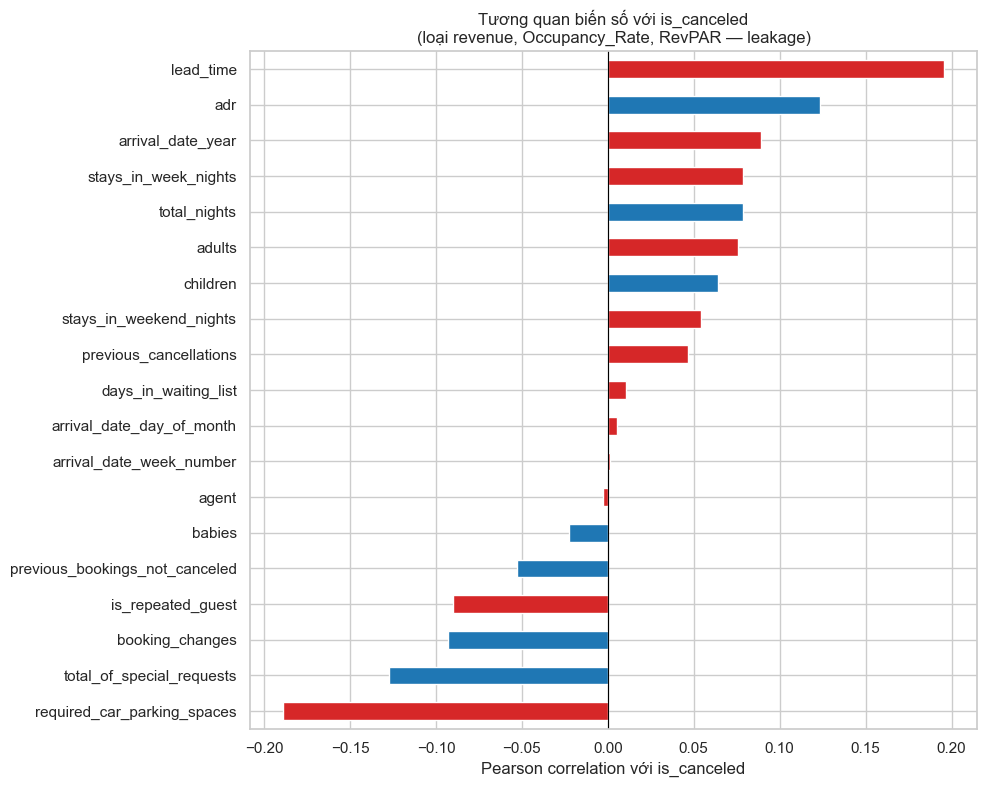

In [3]:
# Bar chart: Pearson correlation với is_canceled (loại biến leakage)
leakage_numeric = {"revenue", "Occupancy_Rate", "RevPAR"}
plot_corr = pearson_corr.drop(
    labels=[c for c in leakage_numeric if c in pearson_corr.index],
    errors="ignore",
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in plot_corr.values]
plot_corr.sort_values().plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation với is_canceled")
ax.set_title("Tương quan biến số với is_canceled\n(loại revenue, Occupancy_Rate, RevPAR — leakage)")
plt.tight_layout()
plt.show()

## 2. Tương quan biến phân loại (Cramér's V)

In [4]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))


cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

cramers_results = []
for col in cat_cols:
    rates = df.groupby(col, observed=True)["is_canceled"].agg(["mean", "count"])
    rates["cancel_pct"] = rates["mean"] * 100
    cramers_results.append({
        "variable": col,
        "cramers_v": cramers_v(df[col].astype(str), df["is_canceled"]),
        "cancel_spread_pp": rates["cancel_pct"].max() - rates["cancel_pct"].min(),
        "n_categories": len(rates),
    })

corr_categorical = (
    pd.DataFrame(cramers_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

print("=== Cramér's V với is_canceled ===")
display(corr_categorical)

=== Cramér's V với is_canceled ===


,variable,cramers_v,cancel_spread_pp,n_categories
0,reservation_status,1.000000,100.000000,3
1,reservation_status_date,0.309310,100.000000,926
2,market_segment,0.218688,87.166939,8
3,country,0.201918,100.000000,178
4,deposit_type,0.161411,67.686703,3
5,distribution_channel,0.150827,66.391612,5
6,customer_type,0.118201,19.801104,4
7,assigned_room_type,0.093569,98.542274,12
8,arrival_date_month,0.083455,10.921639,12
9,hotel,0.071501,6.599289,2


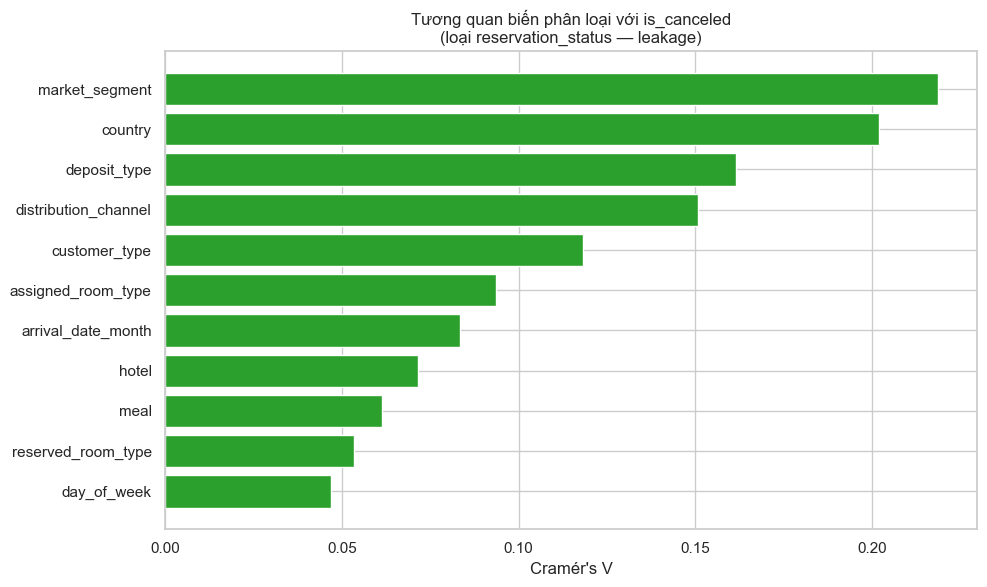

In [5]:
leakage_cat = {"reservation_status", "reservation_status_date"}
plot_cat = corr_categorical[~corr_categorical["variable"].isin(leakage_cat)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_cat["variable"], plot_cat["cramers_v"], color="#2ca02c", edgecolor="white")
ax.set_xlabel("Cramér's V")
ax.set_title("Tương quan biến phân loại với is_canceled\n(loại reservation_status — leakage)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Heatmap — Ma trận tương quan biến số

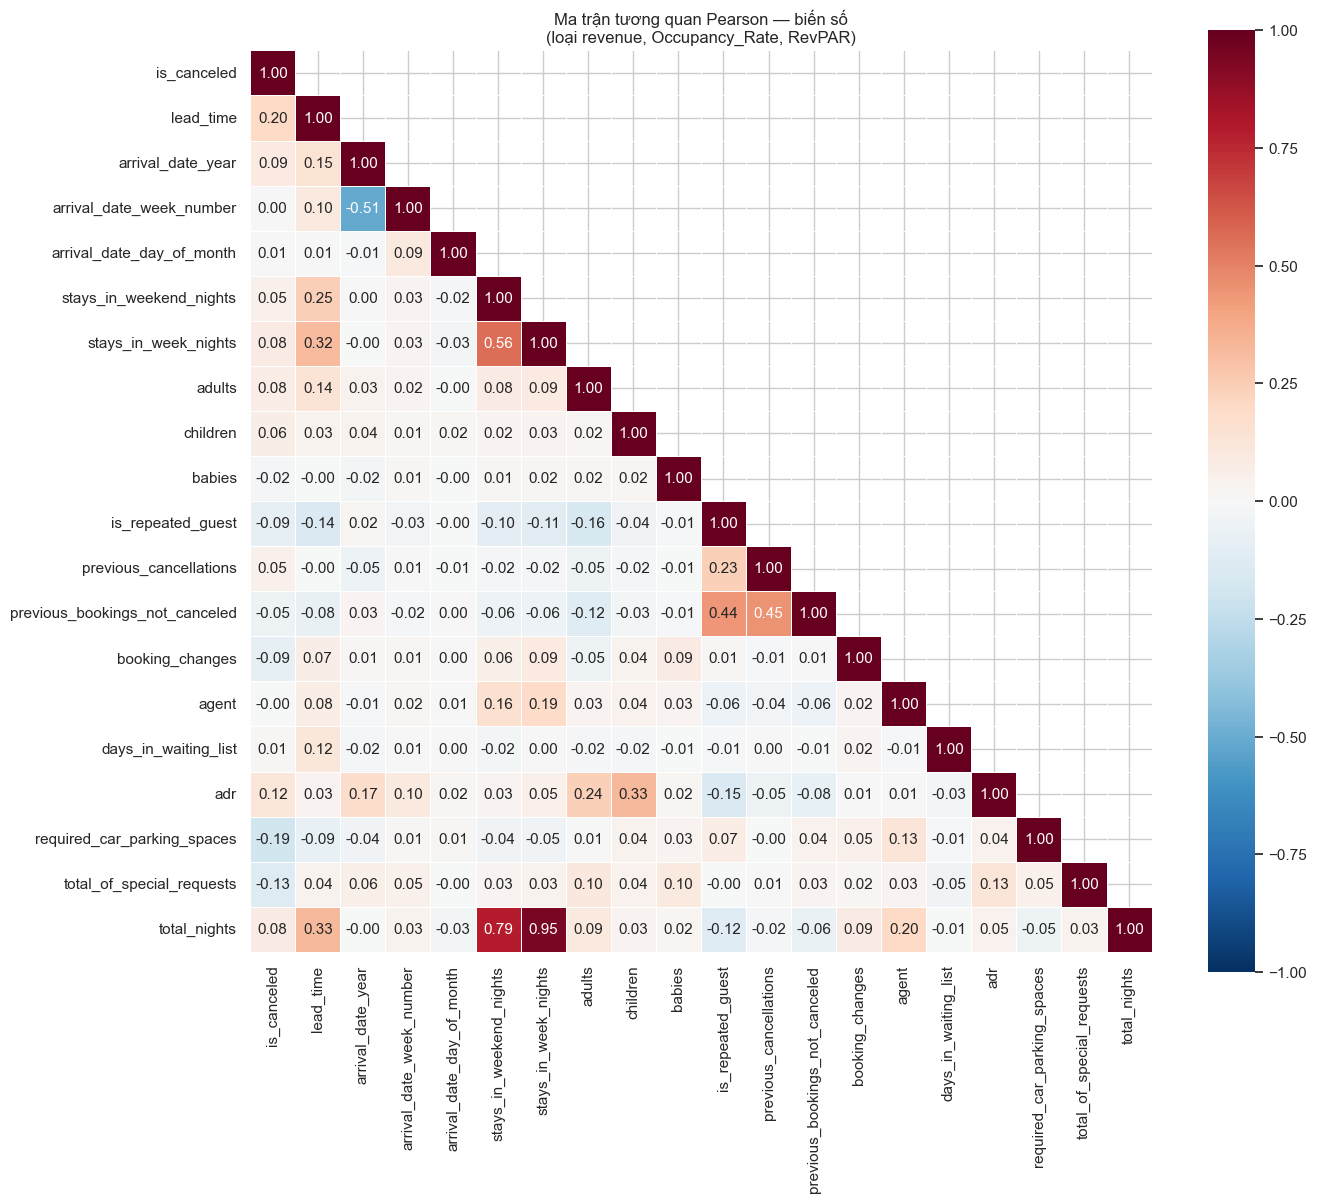

In [6]:
# Loại biến leakage khỏi heatmap đầy đủ
leakage_all = leakage_numeric | leakage_cat
num_for_heatmap = [c for c in num_cols if c not in leakage_numeric]

corr_matrix = df[num_for_heatmap].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Ma trận tương quan Pearson — biến số\n(loại revenue, Occupancy_Rate, RevPAR)")
plt.tight_layout()
plt.show()

## 4. Heatmap tổng hợp — Tất cả biến vs `is_canceled`

Gộp |Pearson| (biến số) và Cramér's V (biến phân loại) vào một biểu đồ so sánh mức độ liên quan.

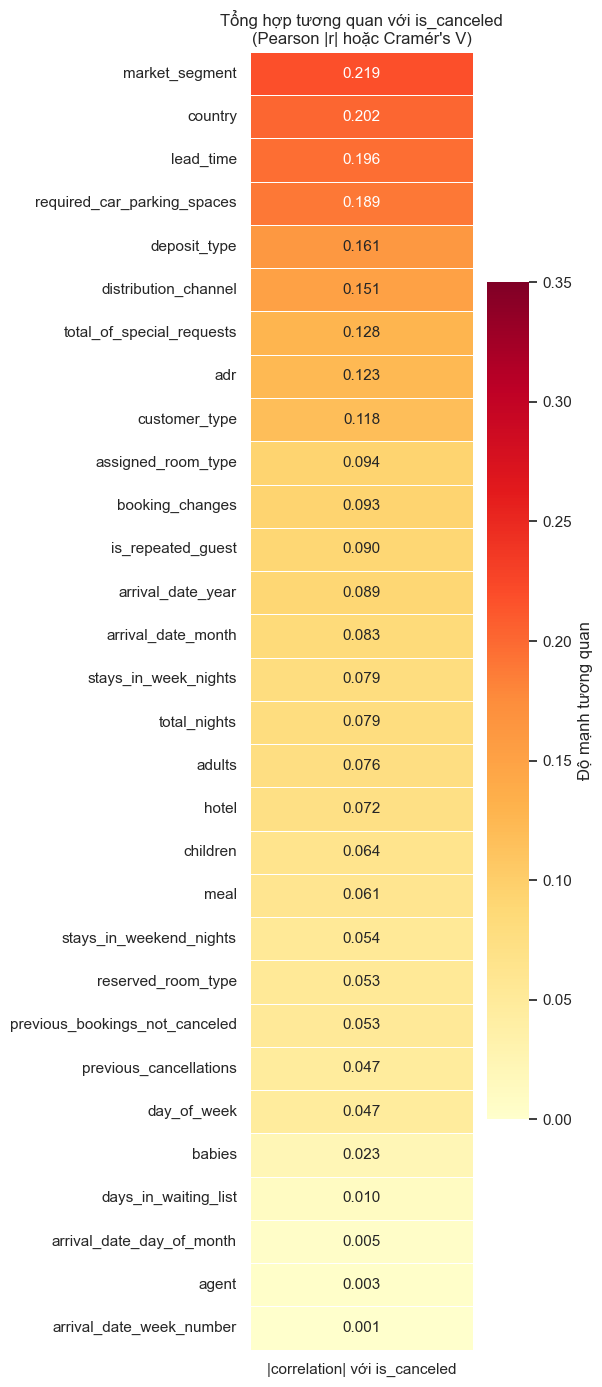

=== Bảng tổng hợp (sắp theo độ mạnh) ===


,variable,type,strength,direction,metric,raw_value
3,market_segment,categorical,0.218688,association,cramers_v,0.218688
4,country,categorical,0.201918,association,cramers_v,0.201918
5,lead_time,numeric,0.195582,positive,pearson,0.195582
6,required_car_parking_spaces,numeric,0.188850,negative,pearson,-0.188850
8,deposit_type,categorical,0.161411,association,cramers_v,0.161411
9,distribution_channel,categorical,0.150827,association,cramers_v,0.150827
10,total_of_special_requests,numeric,0.127511,negative,pearson,-0.127511
11,adr,numeric,0.123334,positive,pearson,0.123334
12,customer_type,categorical,0.118201,association,cramers_v,0.118201
13,assigned_room_type,categorical,0.093569,association,cramers_v,0.093569


In [7]:
combined_rows = []

for var, r in pearson_corr.items():
    combined_rows.append({
        "variable": var,
        "type": "numeric",
        "strength": abs(r),
        "direction": "positive" if r > 0 else "negative",
        "metric": "pearson",
        "raw_value": r,
    })

for _, row in corr_categorical.iterrows():
    combined_rows.append({
        "variable": row["variable"],
        "type": "categorical",
        "strength": row["cramers_v"],
        "direction": "association",
        "metric": "cramers_v",
        "raw_value": row["cramers_v"],
    })

combined_corr = (
    pd.DataFrame(combined_rows)
    .sort_values("strength", ascending=False)
    .reset_index(drop=True)
)

# Loại leakage để vẽ heatmap 1 cột
plot_combined = combined_corr[
    ~combined_corr["variable"].isin(leakage_all)
].copy()

heatmap_data = plot_combined[["variable", "strength"]].set_index("variable")
heatmap_data.columns = ["|correlation| với is_canceled"]

fig, ax = plt.subplots(figsize=(6, 14))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.35,
    linewidths=0.5,
    cbar_kws={"label": "Độ mạnh tương quan"},
    ax=ax,
)
ax.set_title("Tổng hợp tương quan với is_canceled\n(Pearson |r| hoặc Cramér's V)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("=== Bảng tổng hợp (sắp theo độ mạnh) ===")
display(plot_combined)

## 5. Phân loại Causation vs Correlation

| Tier | Nhãn | Ý nghĩa |
|------|------|---------|
| **Leakage** | Không dùng | Biến hậu quả / derived từ `is_canceled` |
| **Causation cao** | Tier 1 | Có thể can thiệp chính sách, thứ tự thời gian rõ |
| **Causation TB** | Tier 2 | Hành vi / cam kết, hữu ích cho model |
| **Confounded** | Tier 3 | Tương quan do biến thứ ba (segment, channel…) |
| **Yếu** | Tier 4 | |r| hoặc V quá thấp |

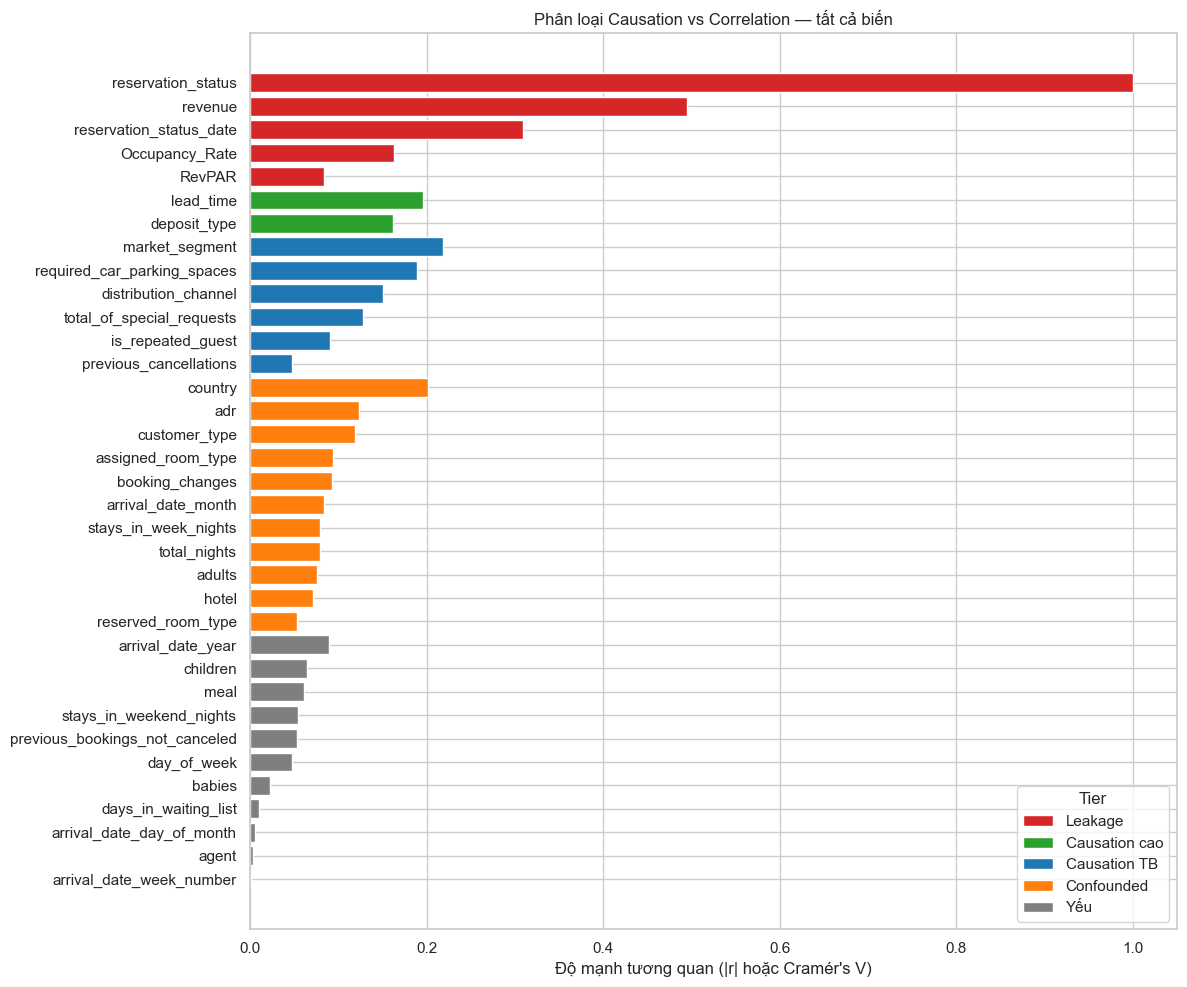

,variable,tier,causation_likelihood,reason,correlation_strength
0,reservation_status,Leakage,Không,Gần như là nhãn của hủy (Canceled = 100%),1.000000
2,revenue,Leakage,Không,revenue = adr × total_nights × (1 - is_canceled),0.494349
1,reservation_status_date,Leakage,Không,Ngày ghi nhận trạng thái — xảy ra sau hủy,0.309310
3,Occupancy_Rate,Leakage,Không,"Biến tổng hợp theo thời gian, phản ánh cả hủy",0.163011
4,RevPAR,Leakage,Không,Biến tổng hợp derived,0.083565
5,lead_time,Causation cao,Cao,Đặt xa → nhiều biến cố → hủy tăng; có ngưỡng 3...,0.195582
6,deposit_type,Causation cao,Cao,"Lever chính sách cọc; 98,7% No Deposit",0.161411
7,market_segment,Causation TB,TB,"Hành vi segment khác nhau (Online TA 35,6% vs ...",0.218688
11,required_car_parking_spaces,Causation TB,TB,Kế hoạch cụ thể (đậu xe) → ít hủy,0.188850
8,distribution_channel,Causation TB,TB,"OTA cho phép hủy dễ hơn Direct (31,7% vs 15,3%)",0.150827


In [8]:
causation_classification = pd.DataFrame([
  # --- Leakage ---
  {"variable": "reservation_status",       "tier": "Leakage",        "causation_likelihood": "Không",  "reason": "Gần như là nhãn của hủy (Canceled = 100%)"},
  {"variable": "reservation_status_date",  "tier": "Leakage",        "causation_likelihood": "Không",  "reason": "Ngày ghi nhận trạng thái — xảy ra sau hủy"},
  {"variable": "revenue",                  "tier": "Leakage",        "causation_likelihood": "Không",  "reason": "revenue = adr × total_nights × (1 - is_canceled)"},
  {"variable": "Occupancy_Rate",           "tier": "Leakage",        "causation_likelihood": "Không",  "reason": "Biến tổng hợp theo thời gian, phản ánh cả hủy"},
  {"variable": "RevPAR",                   "tier": "Leakage",        "causation_likelihood": "Không",  "reason": "Biến tổng hợp derived"},
  # --- Tier 1: Causation cao ---
  {"variable": "lead_time",                "tier": "Causation cao",  "causation_likelihood": "Cao",    "reason": "Đặt xa → nhiều biến cố → hủy tăng; có ngưỡng 30 ngày (EDA)"},
  {"variable": "deposit_type",             "tier": "Causation cao",  "causation_likelihood": "Cao",    "reason": "Lever chính sách cọc; 98,7% No Deposit"},
  # --- Tier 2: Causation trung bình ---
  {"variable": "market_segment",           "tier": "Causation TB",   "causation_likelihood": "TB",     "reason": "Hành vi segment khác nhau (Online TA 35,6% vs Corporate 12,9%)"},
  {"variable": "distribution_channel",     "tier": "Causation TB",   "causation_likelihood": "TB",     "reason": "OTA cho phép hủy dễ hơn Direct (31,7% vs 15,3%)"},
  {"variable": "previous_cancellations",   "tier": "Causation TB",   "causation_likelihood": "TB",     "reason": "Lịch sử hủy dự báo hành vi tương lai"},
  {"variable": "total_of_special_requests","tier": "Causation TB",  "causation_likelihood": "TB",     "reason": "Yêu cầu cụ thể = cam kết cao hơn → ít hủy"},
  {"variable": "required_car_parking_spaces","tier": "Causation TB","causation_likelihood": "TB",     "reason": "Kế hoạch cụ thể (đậu xe) → ít hủy"},
  {"variable": "is_repeated_guest",        "tier": "Causation TB",   "causation_likelihood": "TB",     "reason": "Khách quen có loyalty → ít hủy"},
  # --- Tier 3: Confounded ---
  {"variable": "adr",                      "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Confounded bởi segment/channel/lead_time"},
  {"variable": "customer_type",            "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Gắn với segment và kênh phân phối"},
  {"variable": "hotel",                    "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "City vs Resort khác mix segment/OTA"},
  {"variable": "booking_changes",          "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Hướng nhân quả không rõ (2 chiều)"},
  {"variable": "stays_in_week_nights",     "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Liên quan Groups/segment"},
  {"variable": "total_nights",             "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Liên quan loại khách/segment"},
  {"variable": "adults",                   "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Proxy cho loại booking"},
  {"variable": "arrival_date_month",       "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Mùa cao điểm ↔ mix OTA/lead_time"},
  {"variable": "country",                  "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Nhiều nước sample < 5 booking"},
  {"variable": "assigned_room_type",       "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Gán phòng có thể sau/sát ngày đến"},
  {"variable": "reserved_room_type",       "tier": "Confounded",     "causation_likelihood": "Thấp",   "reason": "Liên quan segment, sample nhỏ ở một số loại"},
  # --- Tier 4: Yếu ---
  {"variable": "agent",                    "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "|r| < 0,01"},
  {"variable": "days_in_waiting_list",     "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "|r| ≈ 0,01"},
  {"variable": "babies",                   "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "|r| < 0,03"},
  {"variable": "children",                 "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "|r| ≈ 0,06"},
  {"variable": "day_of_week",              "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "Spread < 7 pp"},
  {"variable": "meal",                     "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "V = 0,06"},
  {"variable": "arrival_date_year",        "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "Xu hướng thời gian, không phải driver trực tiếp"},
  {"variable": "arrival_date_week_number", "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "|r| ≈ 0"},
  {"variable": "arrival_date_day_of_month","tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "|r| ≈ 0"},
  {"variable": "previous_bookings_not_canceled","tier": "Yếu",       "causation_likelihood": "Rất thấp","reason": "|r| ≈ 0,05"},
  {"variable": "stays_in_weekend_nights", "tier": "Yếu",            "causation_likelihood": "Rất thấp","reason": "|r| ≈ 0,05"},
])

# Gắn giá trị tương quan thực tế
strength_map = dict(zip(combined_corr["variable"], combined_corr["strength"]))
causation_classification["correlation_strength"] = (
    causation_classification["variable"].map(strength_map)
)

tier_order = ["Leakage", "Causation cao", "Causation TB", "Confounded", "Yếu"]
causation_classification["tier"] = pd.Categorical(
    causation_classification["tier"], categories=tier_order, ordered=True
)
causation_classification = causation_classification.sort_values(["tier", "correlation_strength"], ascending=[True, False])

tier_colors = {
    "Leakage": "#d62728",
    "Causation cao": "#2ca02c",
    "Causation TB": "#1f77b4",
    "Confounded": "#ff7f0e",
    "Yếu": "#7f7f7f",
}

fig, ax = plt.subplots(figsize=(12, 10))
for tier in tier_order:
    subset = causation_classification[causation_classification["tier"] == tier]
    ax.barh(
        subset["variable"],
        subset["correlation_strength"].fillna(0),
        label=tier,
        color=tier_colors[tier],
        edgecolor="white",
    )
ax.set_xlabel("Độ mạnh tương quan (|r| hoặc Cramér's V)")
ax.set_title("Phân loại Causation vs Correlation — tất cả biến")
ax.legend(title="Tier", loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(causation_classification)

## 6. Kiểm tra Partial Correlation (confounding)

Kiểm soát `deposit_type` khi đo tương quan `lead_time` ↔ `is_canceled` và ngược lại.

In [9]:
from numpy.linalg import lstsq

dep_map = {"No Deposit": 0, "Refundable": 1, "Non Refund": 2}
df["dep_enc"] = df["deposit_type"].map(dep_map)


def partial_corr(x: str, y: str, controls: list[str], data: pd.DataFrame) -> float:
    cols = [x, y, *controls]
    sub = data[cols].dropna()
    if len(sub) < 10:
        return np.nan

    def residuals(var: str, others: list[str]) -> np.ndarray:
        X = np.column_stack([np.ones(len(sub)), sub[others].values])
        beta = lstsq(X, sub[var].values, rcond=None)[0]
        return sub[var].values - X @ beta

    rx = residuals(x, controls)
    ry = residuals(y, controls)
    return float(np.corrcoef(rx, ry)[0, 1])


partial_results = pd.DataFrame([
    {
        "pair": "lead_time ↔ is_canceled",
        "control": "deposit_type",
        "pearson_raw": pearson_corr["lead_time"],
        "partial_corr": partial_corr("lead_time", "is_canceled", ["dep_enc"], df),
    },
    {
        "pair": "deposit_type ↔ is_canceled",
        "control": "lead_time",
        "pearson_raw": np.nan,
        "partial_corr": partial_corr("dep_enc", "is_canceled", ["lead_time"], df),
    },
])
display(partial_results)

print("\n=== Kết luận ===")
print("• lead_time vẫn tương quan dương sau khi kiểm soát deposit → không chỉ do confounding.")
print("• deposit_type vẫn có hiệu ứng sau khi kiểm soát lead_time → cả hai đều là candidate causation.")
print("• Dùng cho modeling: lead_time, deposit_type, market_segment, distribution_channel,")
print("  previous_cancellations, total_of_special_requests, is_repeated_guest.")
print("• KHÔNG dùng: reservation_status, revenue, Occupancy_Rate, RevPAR.")

,pair,control,pearson_raw,partial_corr
0,lead_time ↔ is_canceled,deposit_type,0.195582,0.172646
1,deposit_type ↔ is_canceled,lead_time,NaN,0.130333



=== Kết luận ===
• lead_time vẫn tương quan dương sau khi kiểm soát deposit → không chỉ do confounding.
• deposit_type vẫn có hiệu ứng sau khi kiểm soát lead_time → cả hai đều là candidate causation.
• Dùng cho modeling: lead_time, deposit_type, market_segment, distribution_channel,
  previous_cancellations, total_of_special_requests, is_repeated_guest.
• KHÔNG dùng: reservation_status, revenue, Occupancy_Rate, RevPAR.
